In [1]:

from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

/Users/baeseong-yeon/Desktop/2026-1/bible-atlas-agent/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from langgraph.prebuilt import ToolNode
from place_tools import search_ancient_places, fetch_modern_places_by_names, journey_search, ancient_keyword_search
tool_list = [search_ancient_places, journey_search, fetch_modern_places_by_names, ancient_keyword_search]
llm_with_tools = llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list) 

In [4]:
from langgraph.graph import MessagesState, StateGraph
graph_builder = StateGraph(MessagesState)

In [5]:
def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [6]:
from langgraph.graph import  END

def should_continue(state: MessagesState):
    messages = state['messages']

    last_ai_message = messages[-1]

    if last_ai_message.tool_calls:
        return 'tools'
    return 'end'

In [7]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)

In [8]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges('agent', should_continue, {
    'tools': 'tools',
    'end': END
})

In [9]:
graph_builder.add_edge('tools','agent')

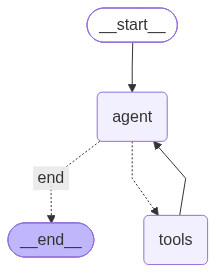

In [10]:
from IPython.display import Image, display
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [15]:
query='바빌론이 현재 정확히 어디야?'

In [16]:
from langchain_core.messages import HumanMessage
for chunk in graph.stream(
    {"messages": [HumanMessage(content=query)]},
    stream_mode="updates",
):
    for node_name, update in chunk.items():
        print(f"\nNode: {node_name}")

        for message in update.get("messages", []):
            message.pretty_print()


Node: agent
================================== Ai Message ==================================
Tool Calls:
  search_ancient_places (call_8c2Ga5dXL5cYuaG1IHzY4LuF)
 Call ID: call_8c2Ga5dXL5cYuaG1IHzY4LuF
  Args:
    keywords: ['바빌론']

Node: tools
================================= Tool Message =================================
Name: search_ancient_places

[{"place_id": "ab8fdbc", "name_ko": "바벨", "name_en": "Babel", "types": ["settlement"], "bible_references": ["Gen.10.10", "Gen.11.9"], "identification_names": ["Babylon / 바빌론"], "text": "Babel\n\n바벨\n\nPossible modern sites: Babylon / 바빌론\n\nThe biblical city associated with the Tower of Babel, where God confused the languages of the people (Gen. 11:9).\nIt is identified with the later city of Babylon in Shinar (Mesopotamia).\n\n성경에서 사람들이 하늘에 닿는 탑(바벨탑)을 쌓으려 했고, 하나님이 언어를 혼잡하게 하신 사건(창 11:9)이 발생한 도시입니다.\n후대의 메소포타미아 시날 땅의 바벨론과 동일시됩니다."}]

Node: agent
================================== Ai Message ==================================
Tool Calls:
